In [1]:
# Import que vous pouvez vouloir pour le TP
import torch
import torch.nn as nn

import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import random_split

import torchvision
import torchvision.transforms as transforms
import numpy as np


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Calcul de la moyenne et de l'écart type pour nos images

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dir = "./data"

transform_base = transforms.Compose([
    transforms.ToTensor()
])
dataset = datasets.ImageFolder(root=dir, transform=transform_base)
loader = DataLoader(dataset, batch_size=64, shuffle=False)

somme_totale = 0.0
somme_carres_totale = 0.0
nombre_total_pixels = 0

for images, _ in loader:
    somme_totale += images.sum()
    somme_carres_totale += (images ** 2).sum()
    nombre_total_pixels += images.numel()
moyenne = somme_totale / nombre_total_pixels
variance = (somme_carres_totale / nombre_total_pixels) - (moyenne ** 2)
ecart_type = torch.sqrt(variance)




Taille du train set : 30384
Taille du test set  : 7596
Nombre de classes   : 10
Noms des classes    : ['coastguard_scaled', 'containership_scaled', 'corvette_scaled', 'cruiser_scaled', 'cv_scaled', 'destroyer_scaled', 'methanier_scaled', 'smallfish_scaled', 'submarine_scaled', 'tug_scaled']
Dimensions d'une image : torch.Size([1, 128, 192])  (C x H x W)
Classe de l'image      : cv_scaled


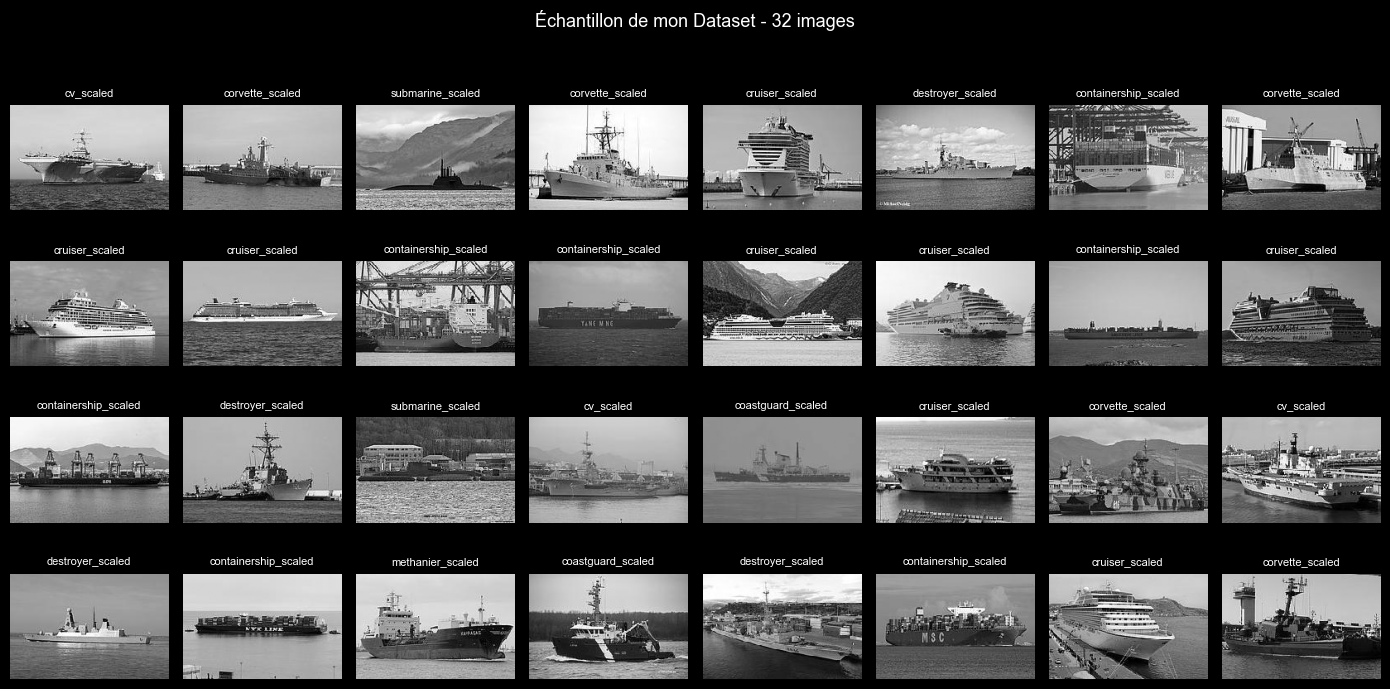

In [3]:
transform_base = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(moyenne.item(), ecart_type.item())
])

dataset_complet = datasets.ImageFolder(root='./data/ships_gray/ships_gray', transform=transform_base)
classes = dataset_complet.classes
taille_totale = len(dataset_complet)
taille_train = int(0.8 * taille_totale)
taille_test = taille_totale - taille_train


trainset, testset = random_split(dataset_complet, [taille_train, taille_test])


print(f"Taille du train set : {len(trainset)}")
print(f"Taille du test set  : {len(testset)}")
print(f"Nombre de classes   : {len(classes)}")
print(f"Noms des classes    : {classes}")

img, label = trainset[0]
print(f"Dimensions d'une image : {img.shape}  (C x H x W)")
print(f"Classe de l'image      : {classes[label]}")

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('Échantillon de mon Dataset - 32 images', fontsize=13, y=1.02)

for i, ax in enumerate(axes.flat):
    img, label = trainset[i]

    img_display = img * ecart_type.item() + moyenne.item()

    img_display = img_display.squeeze()

    ax.imshow(img_display.numpy(), cmap='gray', vmin=0, vmax=1)

    ax.set_title(classes[label], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

Taille du train set : 30384
Taille du test set  : 7596


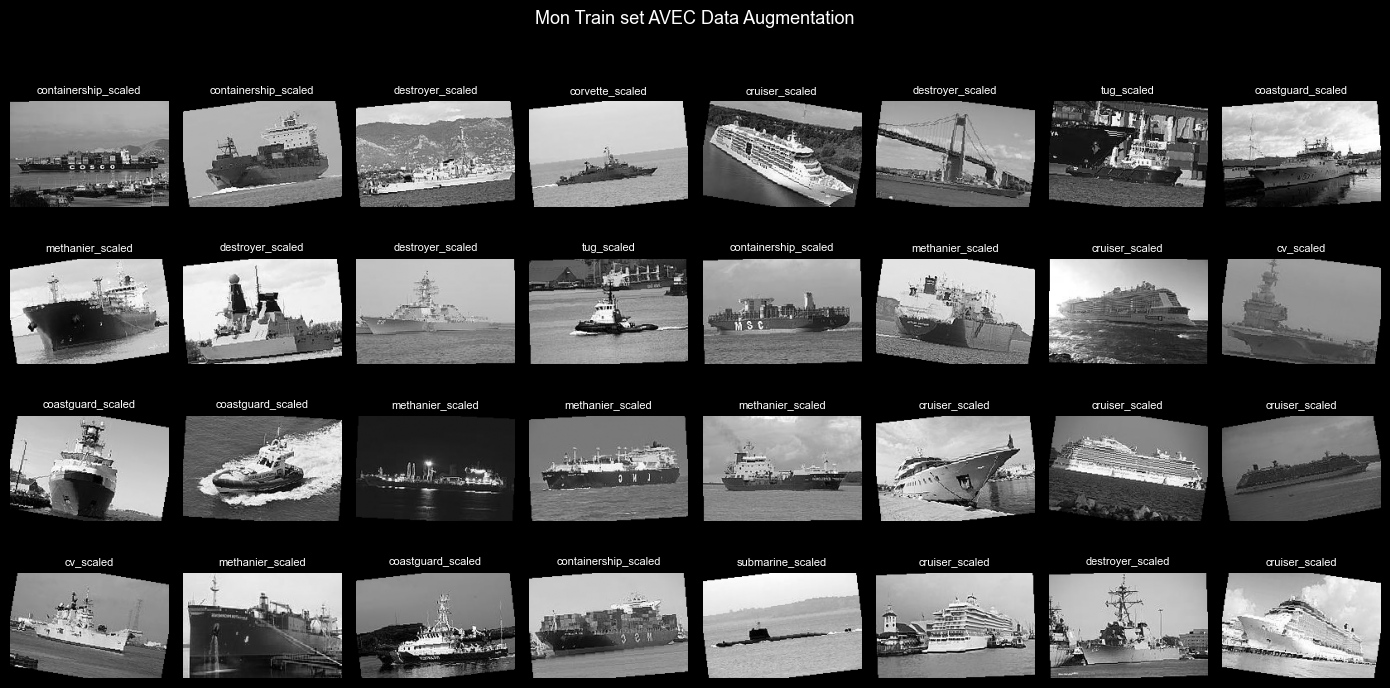

In [9]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, Dataset
import matplotlib.pyplot as plt


transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([moyenne.item()], [ecart_type.item()])
])


transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([moyenne.item()], [ecart_type.item()])
])


dataset_brut = datasets.ImageFolder(root='./data/ships_gray/ships_gray')
classes = dataset_brut.classes

taille_totale = len(dataset_brut)
taille_train = int(0.8 * taille_totale)
taille_test = taille_totale - taille_train


trainset_brut, testset_brut = random_split(dataset_brut, [taille_train, taille_test])

class AugTransform(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.subset[index]

        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

trainset = AugTransform(trainset_brut, transform=transform_train)
testset = AugTransform(testset_brut, transform=transform_test)

print(f"Taille du train set : {len(trainset)}")
print(f"Taille du test set  : {len(testset)}")

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('Mon Train set AVEC Data Augmentation', fontsize=13, y=1.02)

for i, ax in enumerate(axes.flat):
    img, label = trainset[i]

    img_display = img * ecart_type.item() + moyenne.item()
    img_display = img_display.squeeze()

    ax.imshow(img_display.numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(classes[label], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()